**Jakub Orchowski, s223281**

# CEL ĆWICZENIA
Segmentacja obrazów metodą watershed oraz eliminacja elementów zasłoniętych z użyciem z-bufora.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import uniform_filter
from skimage.segmentation import find_boundaries, watershed
%matplotlib inline

# Zadania

## Zadanie 1.
Obraz `alpy.png` wygładzam przez trzykrotne zastosowanie operatora uśredniającego 7x7, a następnie dzielę go na obszary funkcją `watershed` z pakietu `skimage.segmentation`.
Na końcu pokazuję granice segmentacji na tle obrazu oryginalnego oraz obrazu po wygładzeniu.

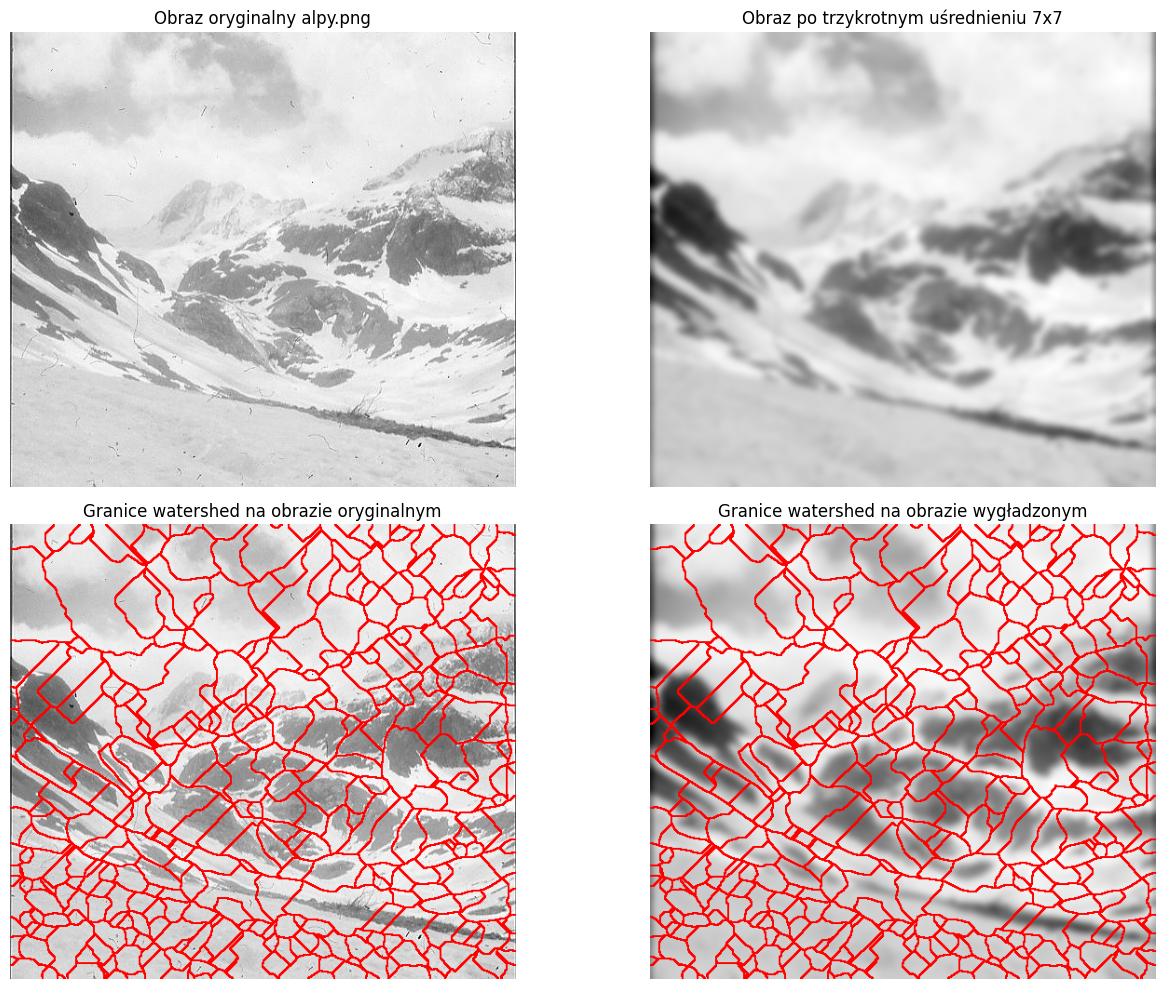

Liczba otrzymanych obszarów: 354
Udział pikseli granicznych: 0.177
Średnia jasność obrazu po wygładzeniu: 208.28


In [ ]:
ALPY_IMAGE = np.array(Image.open("alpy.png").convert("L"), dtype=np.float64)


def normalize(image: np.ndarray) -> np.ndarray:
    """Skaluje obraz do zakresu [0, 1] z ochroną przed dzieleniem przez zero."""
    image = np.asarray(image, dtype=np.float64)
    minimum = image.min()
    maximum = image.max()
    if np.isclose(maximum, minimum):
        return np.zeros_like(image, dtype=np.float64)
    return (image - minimum) / (maximum - minimum)


def mean_filter(image: np.ndarray, kernel_size: int = 7) -> np.ndarray:
    """Wykonuje filtrację uśredniającą funkcją uniform_filter z pakietu scipy.ndimage."""
    image = np.asarray(image, dtype=np.float64)
    return uniform_filter(image, size=kernel_size, mode="nearest")


def repeated_mean_filter(image: np.ndarray, kernel_size: int = 7, repeats: int = 3) -> np.ndarray:
    """Powtarza filtrację uśredniającą zadaną liczbę razy."""
    result = np.asarray(image, dtype=np.float64)
    for _ in range(repeats):
        result = mean_filter(result, kernel_size)
    return result


def apply_watershed(image: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Segmentuje obraz funkcją watershed z pakietu scikit-image."""
    labels = watershed(image, connectivity=2)
    boundaries = find_boundaries(labels, connectivity=2, mode="thick")
    return labels, boundaries


def overlay_boundaries(base_image: np.ndarray, boundaries: np.ndarray, color: tuple[float, float, float] = (1.0, 0.0, 0.0)) -> np.ndarray:
    """Nakłada granice segmentacji na obraz w skali szarości."""
    base = normalize(base_image)
    overlay = np.dstack([base, base, base])
    overlay[boundaries] = color
    return overlay


alpy_smoothed = repeated_mean_filter(ALPY_IMAGE, kernel_size=7, repeats=3)
task1_labels, task1_boundaries = apply_watershed(alpy_smoothed)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].imshow(ALPY_IMAGE, cmap="gray")
axes[0, 0].set_title("Obraz oryginalny alpy.png")
axes[0, 0].axis("off")

axes[0, 1].imshow(alpy_smoothed, cmap="gray")
axes[0, 1].set_title("Obraz po trzykrotnym uśrednieniu 7x7")
axes[0, 1].axis("off")

axes[1, 0].imshow(overlay_boundaries(ALPY_IMAGE, task1_boundaries))
axes[1, 0].set_title("Granice watershed na obrazie oryginalnym")
axes[1, 0].axis("off")

axes[1, 1].imshow(overlay_boundaries(alpy_smoothed, task1_boundaries))
axes[1, 1].set_title("Granice watershed na obrazie wygładzonym")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


### Wnioski
Po samym wygładzeniu liczba lokalnych minimów maleje, ale segmentacja nadal reaguje na drobne zmiany jasności i cieniowanie zboczy.
Wynik ma częściowy sens geometryczny, jednak bardziej opisuje lokalne doliny poziomu szarości niż duże, semantyczne fragmenty krajobrazu.

## Zadanie 2.
Powtarzam segmentację dla obrazu gradientowego wyznaczonego z wcześniej wygładzonego wejścia. Gradient normalizuję do zakresu [0, 1], ponownie trzykrotnie uśredniam i dopiero wtedy stosuję funkcję `watershed`.
Wynik porównuję z obrazem oryginalnym oraz z obrazem po wygładzeniu.

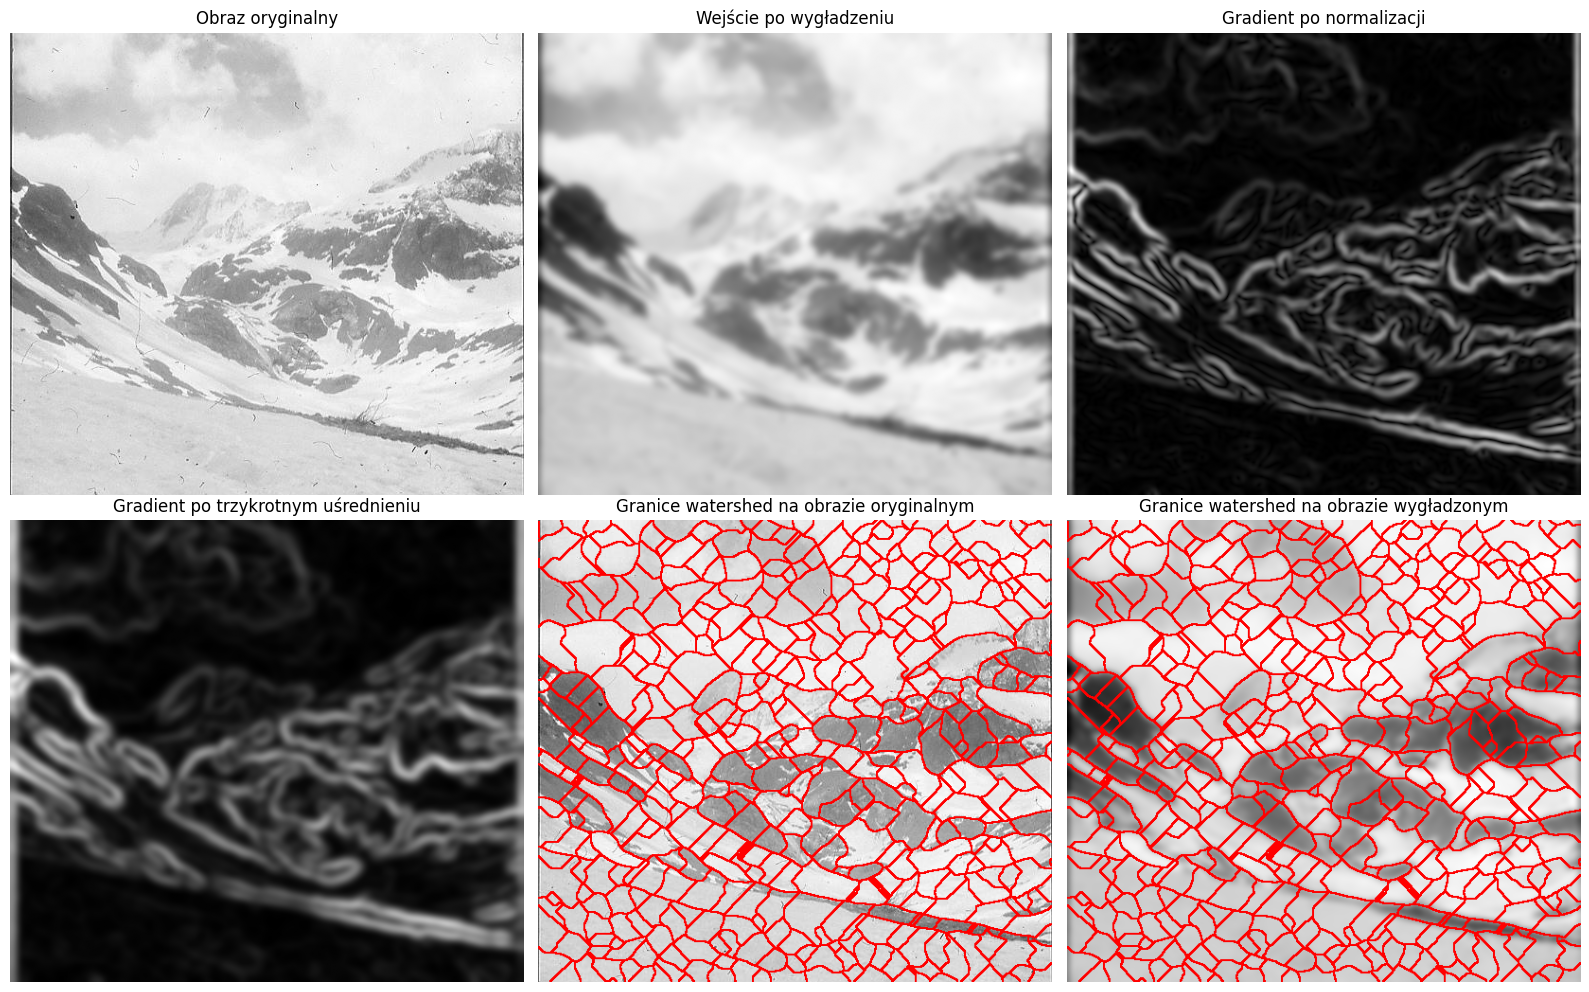

Liczba otrzymanych obszarów: 444
Udział pikseli granicznych: 0.204
Średnia wartość wygładzonego gradientu: 0.1209


In [8]:
gradient_y, gradient_x = np.gradient(alpy_smoothed)
gradient_image = normalize(np.hypot(gradient_x, gradient_y))
gradient_smoothed = repeated_mean_filter(gradient_image, kernel_size=7, repeats=3)
task2_labels, task2_boundaries = apply_watershed(gradient_smoothed)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes[0, 0].imshow(ALPY_IMAGE, cmap="gray")
axes[0, 0].set_title("Obraz oryginalny")
axes[0, 0].axis("off")

axes[0, 1].imshow(alpy_smoothed, cmap="gray")
axes[0, 1].set_title("Wejście po wygładzeniu")
axes[0, 1].axis("off")

axes[0, 2].imshow(gradient_image, cmap="gray")
axes[0, 2].set_title("Gradient po normalizacji")
axes[0, 2].axis("off")

axes[1, 0].imshow(gradient_smoothed, cmap="gray")
axes[1, 0].set_title("Gradient po trzykrotnym uśrednieniu")
axes[1, 0].axis("off")

axes[1, 1].imshow(overlay_boundaries(ALPY_IMAGE, task2_boundaries))
axes[1, 1].set_title("Granice watershed na obrazie oryginalnym")
axes[1, 1].axis("off")

axes[1, 2].imshow(overlay_boundaries(alpy_smoothed, task2_boundaries))
axes[1, 2].set_title("Granice watershed na obrazie wygładzonym")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print(f"Liczba otrzymanych obszarów: {int(np.unique(task2_labels).size)}")
print(f"Udział pikseli granicznych: {task2_boundaries.mean():.3f}")
print(f"Średnia wartość wygładzonego gradientu: {gradient_smoothed.mean():.4f}")

### Wnioski
Watershed zastosowany do wygładzonego gradientu lepiej podkreśla miejsca gwałtownych zmian jasności, więc granice obszarów są bliżej faktycznych konturów sceny.
Jednocześnie liczba zlewni nadal pozostaje duża, dlatego poprawa dotyczy głównie położenia granic, a nie pełnego uproszczenia segmentacji.

## Zadanie 3.
Tworzę dwa obrazy łącznego widoku przekształconych trójkątów o jasnościach 100 i 200. Do rasteryzacji stosuję bufor głębokości, a macierze obrotu RPYT oraz rzutu perspektywicznego zachowują konwencję z Laboratorium 4.
Pokazuję wynik dla rzutu równoległego wzdłuż osi OZ oraz dla rzutu perspektywicznego z ogniskową `f = 1`.

In [9]:
IMAGE_SHAPE = (400, 400)
PIXEL_SIZE = (0.01, 0.01)
TRIANGLE_3D = np.array(
    [
        [0.0, 0.0, 0.0],
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
    ],
    dtype=np.float64,
)


def rpyt_matrix(roll: float, pitch: float, yaw: float, px: float, py: float, pz: float) -> np.ndarray:
    """Buduje macierz jednorodną zgodną z funkcją RPYT z poprzedniego laboratorium."""
    r = np.deg2rad(roll)
    p = np.deg2rad(pitch)
    y = np.deg2rad(yaw)
    mr = np.array(
        [
            [np.cos(r), -np.sin(r), 0.0],
            [np.sin(r), np.cos(r), 0.0],
            [0.0, 0.0, 1.0],
        ]
    )
    mp = np.array(
        [
            [np.cos(p), 0.0, np.sin(p)],
            [0.0, 1.0, 0.0],
            [-np.sin(p), 0.0, np.cos(p)],
        ]
    )
    my = np.array(
        [
            [1.0, 0.0, 0.0],
            [0.0, np.cos(y), -np.sin(y)],
            [0.0, np.sin(y), np.cos(y)],
        ]
    )
    matrix = np.eye(4)
    matrix[:3, :3] = my @ mp @ mr
    matrix[:3, 3] = [px, py, pz]
    return matrix


def perspective_matrix(f: float) -> np.ndarray:
    """Buduje macierz rzutu perspektywicznego zgodną z funkcją Persp z poprzedniego laboratorium."""
    matrix = np.zeros((4, 4), dtype=np.float64)
    matrix[0, 0] = 1.0
    matrix[1, 1] = 1.0
    matrix[3, 2] = -1.0 / f
    matrix[3, 3] = 1.0
    return matrix


def transform_points(points: np.ndarray, matrix: np.ndarray) -> np.ndarray:
    """Przekształca zbiór punktów 3D macierzą jednorodną 4x4."""
    homogeneous = np.hstack([points, np.ones((points.shape[0], 1))])
    transformed = (matrix @ homogeneous.T).T
    return transformed[:, :3] / transformed[:, 3:4]


def project_parallel(points: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Realizuje rzut równoległy wzdłuż osi OZ."""
    return points[:, :2], np.ones(points.shape[0], dtype=np.float64)


def project_perspective(points: np.ndarray, f: float = 1.0) -> tuple[np.ndarray, np.ndarray]:
    """Rzutuje punkty zgodnie z macierzą Persp i zwraca współczynnik w do interpolacji."""
    homogeneous = np.hstack([points, np.ones((points.shape[0], 1))])
    projected = (perspective_matrix(f) @ homogeneous.T).T
    w_values = projected[:, 3]
    if np.any(np.isclose(w_values, 0.0)):
        raise ValueError("Punkt leży na osobliwej płaszczyźnie rzutu perspektywicznego.")
    return projected[:, :2] / w_values[:, None], w_values


def math_to_pixel(points: np.ndarray, image_shape: tuple[int, int] = IMAGE_SHAPE, pixel_size: tuple[float, float] = PIXEL_SIZE) -> np.ndarray:
    """Przekształca współrzędne matematyczne na współrzędne pikselowe."""
    height, width = image_shape
    dx, dy = pixel_size
    x_pixels = points[:, 0] / dx + width / 2.0
    y_pixels = -points[:, 1] / dy + height / 2.0
    return np.column_stack([x_pixels, y_pixels])


def barycentric_coordinates(points: np.ndarray, triangle: np.ndarray) -> np.ndarray:
    """Liczy współrzędne barycentryczne punktów względem trójkąta w 2D."""
    a, b, c = triangle
    denominator = (b[1] - c[1]) * (a[0] - c[0]) + (c[0] - b[0]) * (a[1] - c[1])
    alpha = ((b[1] - c[1]) * (points[..., 0] - c[0]) + (c[0] - b[0]) * (points[..., 1] - c[1])) / denominator
    beta = ((c[1] - a[1]) * (points[..., 0] - c[0]) + (a[0] - c[0]) * (points[..., 1] - c[1])) / denominator
    gamma = 1.0 - alpha - beta
    return np.stack([alpha, beta, gamma], axis=-1)


def rasterize_triangle(image: np.ndarray, z_buffer: np.ndarray, pixel_vertices: np.ndarray, depths: np.ndarray, brightness: int, clip_w: np.ndarray | None = None) -> None:
    """Wypełnia rzut trójkąta i aktualizuje bufor głębokości."""
    x_min = max(int(np.floor(pixel_vertices[:, 0].min())), 0)
    x_max = min(int(np.ceil(pixel_vertices[:, 0].max())), image.shape[1] - 1)
    y_min = max(int(np.floor(pixel_vertices[:, 1].min())), 0)
    y_max = min(int(np.ceil(pixel_vertices[:, 1].max())), image.shape[0] - 1)
    if x_min > x_max or y_min > y_max:
        return

    x_coords = np.arange(x_min, x_max + 1, dtype=np.float64) + 0.5
    y_coords = np.arange(y_min, y_max + 1, dtype=np.float64) + 0.5
    grid_x, grid_y = np.meshgrid(x_coords, y_coords)
    grid_points = np.stack([grid_x, grid_y], axis=-1)
    barycentric = barycentric_coordinates(grid_points, pixel_vertices)
    inside = np.all(barycentric >= -1e-9, axis=-1)

    if clip_w is None:
        depth_map = np.sum(barycentric * depths, axis=-1)
    else:
        inverse_w = 1.0 / clip_w
        numerator = np.sum(barycentric * (depths * inverse_w), axis=-1)
        denominator = np.sum(barycentric * inverse_w, axis=-1)
        valid = np.abs(denominator) > 1e-12
        depth_map = np.zeros_like(numerator)
        depth_map[valid] = numerator[valid] / denominator[valid]
        inside &= valid

    target_z = z_buffer[y_min:y_max + 1, x_min:x_max + 1]
    target_image = image[y_min:y_max + 1, x_min:x_max + 1]
    update_mask = inside & (depth_map < target_z)
    target_z[update_mask] = depth_map[update_mask]
    target_image[update_mask] = brightness


def render_scene(triangle_specs: list[dict[str, object]], projection: str) -> tuple[np.ndarray, np.ndarray]:
    """Renderuje scenę z dwóch trójkątów przy zadanym typie rzutu."""
    image = np.zeros(IMAGE_SHAPE, dtype=np.uint8)
    z_buffer = np.full(IMAGE_SHAPE, np.inf, dtype=np.float64)

    for spec in triangle_specs:
        transformed = spec["points_3d"]
        if projection == "rownolegly":
            projected, clip_w = project_parallel(transformed)
            rasterize_triangle(image, z_buffer, math_to_pixel(projected), transformed[:, 2], int(spec["brightness"]))
        elif projection == "perspektywiczny":
            projected, clip_w = project_perspective(transformed, f=1.0)
            rasterize_triangle(image, z_buffer, math_to_pixel(projected), transformed[:, 2], int(spec["brightness"]), clip_w)
        else:
            raise ValueError("Nieznany typ projekcji.")

    return image, z_buffer

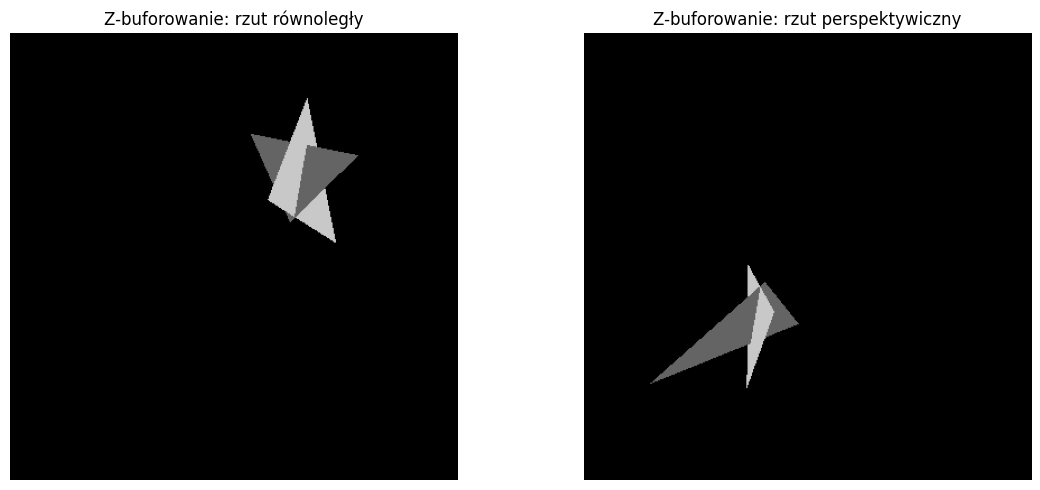

Trójkąt 1:
Wierzchołki po transformacji:
[[0.5   0.3   2.3  ]
 [1.112 0.899 1.784]
 [0.146 1.091 2.799]]
Zakres głębokości Z: 1.784 - 2.799

Trójkąt 2:
Wierzchołki po transformacji:
[[0.3   0.5   2.   ]
 [0.912 0.114 2.69 ]
 [0.654 1.414 2.198]]
Zakres głębokości Z: 2.000 - 2.690

Rzut równoległy: piksele niezerowe = 4912, jasność 100 = 2345, jasność 200 = 2567
Rzut perspektywiczny: piksele niezerowe = 3805, jasność 100 = 2789, jasność 200 = 1016
Zakres zapisanych głębokości dla rzutu równoległego: 1.791 - 2.789
Zakres zapisanych głębokości dla rzutu perspektywicznego: 1.788 - 2.791


In [10]:
triangle_specs = [
    {
        "name": "Trójkąt 1",
        "angles": (30.0, 45.0, 10.0),
        "translation": (0.5, 0.3, 2.3),
        "brightness": 100,
    },
    {
        "name": "Trójkąt 2",
        "angles": (-30.0, -45.0, -10.0),
        "translation": (0.3, 0.5, 2.0),
        "brightness": 200,
    },
]

transformed_triangles = []
for spec in triangle_specs:
    points_3d = transform_points(TRIANGLE_3D, rpyt_matrix(*spec["angles"], *spec["translation"]))
    transformed_triangles.append({**spec, "points_3d": points_3d})

parallel_image, parallel_z = render_scene(transformed_triangles, "rownolegly")
perspective_image, perspective_z = render_scene(transformed_triangles, "perspektywiczny")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(parallel_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Z-buforowanie: rzut równoległy")
axes[0].axis("off")

axes[1].imshow(perspective_image, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Z-buforowanie: rzut perspektywiczny")
axes[1].axis("off")

plt.tight_layout()
plt.show()

for triangle in transformed_triangles:
    z_values = triangle["points_3d"][:, 2]
    print(f"{triangle['name']}:")
    print("Wierzchołki po transformacji:")
    print(np.round(triangle["points_3d"], 3))
    print(f"Zakres głębokości Z: {z_values.min():.3f} - {z_values.max():.3f}")
    print()

parallel_visible = parallel_z[np.isfinite(parallel_z)]
perspective_visible = perspective_z[np.isfinite(perspective_z)]

print(f"Rzut równoległy: piksele niezerowe = {np.count_nonzero(parallel_image)}, jasność 100 = {np.count_nonzero(parallel_image == 100)}, jasność 200 = {np.count_nonzero(parallel_image == 200)}")
print(f"Rzut perspektywiczny: piksele niezerowe = {np.count_nonzero(perspective_image)}, jasność 100 = {np.count_nonzero(perspective_image == 100)}, jasność 200 = {np.count_nonzero(perspective_image == 200)}")
print(f"Zakres zapisanych głębokości dla rzutu równoległego: {parallel_visible.min():.3f} - {parallel_visible.max():.3f}")
print(f"Zakres zapisanych głębokości dla rzutu perspektywicznego: {perspective_visible.min():.3f} - {perspective_visible.max():.3f}")

### Wnioski
Bufor głębokości poprawnie rozstrzyga, który z trójkątów jest widoczny w danym pikselu, więc kolejność rysowania nie wpływa na wynik końcowy.
Rzut perspektywiczny zmienia skalę i położenie figur zgodnie z konwencją z poprzedniego laboratorium, a rzut równoległy zachowuje ich rozmiary niezależnie od odległości w osi Z.